<a href="https://colab.research.google.com/github/mirrash7/Experiments/blob/main/ghostfont_decoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 👻 Ghost Font Decoder — recovering motion-hidden text with computer vision

[ghostfont.org](https://ghostfont.org/) hides a word in a **random-dot kinematogram**: the letters are a
region whose dots move *opposite* to the background. Any single frame is noise, so screenshot-OCR fails —
but the word is fully present in the **motion field**.

This notebook recovers it:

1. **Load frames** from a screen-recording (or auto-capture the live site).
2. **Dense optical flow** between consecutive frames (per-pixel motion vectors).
3. **Temporal accumulation** — average the flow over time so coherent letter-motion reinforces while random noise cancels.
4. **Motion segmentation** — letters are the pixels moving *against* the dominant background direction.
5. **OCR** the reconstructed word.

> Tip: run the cells top to bottom. The reliable input path is **upload a screen recording**; the
> Playwright auto-capture at the bottom is a convenience and may need tuning.

## 1 · Install dependencies

In [ ]:
# Run once. (Colab won't need a runtime restart for these.)
!pip install -q opencv-python-headless imageio imageio-ffmpeg pytesseract
!apt-get -qq install -y tesseract-ocr > /dev/null
print("Dependencies installed.")

Dependencies installed.


In [ ]:
import cv2, numpy as np, imageio.v2 as imageio
import matplotlib.pyplot as plt
from pathlib import Path
import pytesseract
np.set_printoptions(precision=3, suppress=True)

## 2 · Load frames

Upload a **screen recording** of the ghostfont animation (`.mp4`, `.mov`, `.webm`) or a `.gif`.
Aim for a few seconds at a high, steady frame rate — the whole method depends on smooth frame-to-frame motion.

In [ ]:
from google.colab import files
uploaded = files.upload()   # pick your recording / gif
INPUT_PATH = list(uploaded.keys())[0]
print("Loaded:", INPUT_PATH)

Saving ghost-font-robots-are-smart.mp4 to ghost-font-robots-are-smart.mp4
Loaded: ghost-font-robots-are-smart.mp4


42 frames, size 720x405


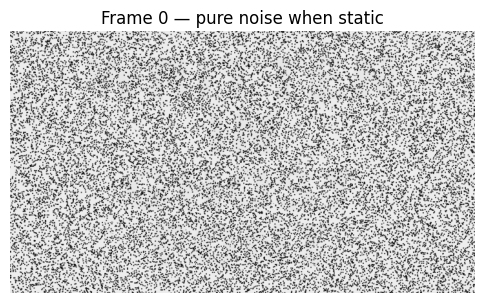

In [ ]:
def load_frames(path, max_frames=240, target_width=720):
    """Decode a video or gif into a list of RGB frames, resized for speed."""
    path = str(path)
    frames = []
    if path.lower().endswith(".gif"):
        for f in imageio.mimread(path, memtest=False):
            f = np.asarray(f)
            if f.ndim == 2:
                f = cv2.cvtColor(f, cv2.COLOR_GRAY2RGB)
            elif f.shape[2] == 4:
                f = cv2.cvtColor(f, cv2.COLOR_RGBA2RGB)
            frames.append(f)
    else:
        cap = cv2.VideoCapture(path)
        while len(frames) < max_frames:
            ok, bgr = cap.read()
            if not ok:
                break
            frames.append(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
        cap.release()
    frames = frames[:max_frames]
    if not frames:
        raise RuntimeError("No frames decoded — check the file.")
    h, w = frames[0].shape[:2]
    if w > target_width:
        s = target_width / w
        frames = [cv2.resize(f, (int(w*s), int(h*s)), interpolation=cv2.INTER_AREA) for f in frames]
    print(f"{len(frames)} frames, size {frames[0].shape[1]}x{frames[0].shape[0]}")
    return frames

frames = load_frames(INPUT_PATH)
plt.figure(figsize=(6,4)); plt.imshow(frames[0])
plt.title("Frame 0 — pure noise when static"); plt.axis("off"); plt.show()

### (Optional) crop to the animated region

If your recording includes static UI (buttons, captions), crop to just the dot field for a cleaner result.
Set `CROP` to `(y0, y1, x0, x1)` or leave it `None`.

In [ ]:
CROP = None  # e.g. (60, 400, 100, 700)
if CROP:
    y0, y1, x0, x1 = CROP
    frames = [f[y0:y1, x0:x1] for f in frames]
    plt.imshow(frames[0]); plt.title("Cropped frame 0"); plt.axis("off"); plt.show()

## 3 · Optical flow + temporal accumulation

We compute dense Farneback optical flow between consecutive frames and **average it over time**.
Within a coherent region the flow direction is stable, so it survives averaging; unstructured noise cancels toward zero.

Averaged 41 flow fields.


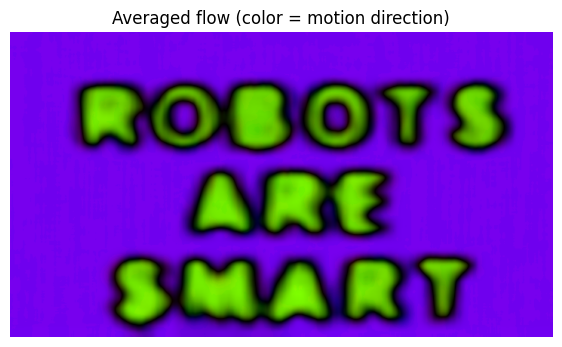

In [ ]:
def accumulate_flow(frames, step=1):
    """Return the time-averaged dense flow field F (H,W,2) and its magnitude."""
    grays = [cv2.cvtColor(f, cv2.COLOR_RGB2GRAY) for f in frames]
    H, W = grays[0].shape
    flow_sum = np.zeros((H, W, 2), np.float32)
    n = 0
    prev = grays[0]
    for i in range(step, len(grays), step):
        nxt = grays[i]
        flow = cv2.calcOpticalFlowFarneback(
            prev, nxt, None,
            pyr_scale=0.5, levels=3, winsize=21,
            iterations=3, poly_n=7, poly_sigma=1.5, flags=0)
        flow_sum += flow
        n += 1
        prev = nxt
    F = flow_sum / max(n, 1)
    mag = np.linalg.norm(F, axis=2)
    print(f"Averaged {n} flow fields.")
    return F, mag

F, mag = accumulate_flow(frames)

# Visualize the averaged flow as an HSV wheel (hue = direction, value = magnitude)
hsv = np.zeros((*mag.shape, 3), np.uint8)
ang = (np.arctan2(F[...,1], F[...,0]) + np.pi) * 180 / (2*np.pi)
hsv[...,0] = ang.astype(np.uint8); hsv[...,1] = 255
hsv[...,2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
plt.figure(figsize=(7,5)); plt.imshow(cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB))
plt.title("Averaged flow (color = motion direction)"); plt.axis("off"); plt.show()
flow_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
imageio.imwrite("flow.png", flow_rgb)

## 4 · Motion segmentation

The letters move **against** the dominant background flow. We estimate the global (magnitude-weighted)
background direction, then score every pixel by how strongly its motion *opposes* it. That score map is,
in effect, a static grayscale picture of the hidden word.

A `kmeans` fallback is included for cases where the two motion fields are equal in area (which makes the
global-direction estimate unreliable) — it clusters the direction field and takes the minority cluster as the letters.

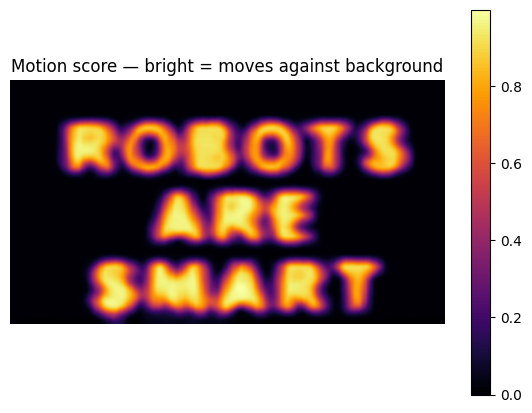

In [ ]:
def motion_score(F, method="projection"):
    H, W, _ = F.shape
    flat = F.reshape(-1, 2)
    w = np.linalg.norm(flat, axis=1, keepdims=True) + 1e-6      # weight by motion strength
    g = (flat * w).sum(0) / w.sum()                              # dominant background vector
    g_hat = g / (np.linalg.norm(g) + 1e-6)
    proj = flat @ g_hat                                          # +: with background, -: against (letters)
    score = (-proj).reshape(H, W)

    if method == "kmeans":
        from sklearn.cluster import KMeans
        km = KMeans(n_clusters=2, n_init=5, random_state=0).fit(flat)
        minority = int(np.argmin(np.bincount(km.labels_)))
        score = (km.labels_ == minority).astype(np.float32).reshape(H, W)

    s = score - score.min()
    return s / (s.max() + 1e-6)

score = motion_score(F, method="projection")     # try method="kmeans" if this is weak
score_gray = (np.clip(score, 0, 1) * 255).astype(np.uint8)
imageio.imwrite("motion_score.png", score_gray)
imageio.imwrite("motion_score_color.png",
                cv2.cvtColor(cv2.applyColorMap(score_gray, cv2.COLORMAP_INFERNO), cv2.COLOR_BGR2RGB))
plt.figure(figsize=(7,5)); plt.imshow(score, cmap="inferno")
plt.title("Motion score — bright = moves against background"); plt.axis("off"); plt.colorbar(); plt.show()

### 5 · OCR

We upscale the reconstruction and try both polarities (dark-on-light and light-on-dark) across a few
Tesseract page-segmentation modes.

In [ ]:
import re

def best_phrase(hits):
    cands = []
    for _name, _psm, txt in hits:
        words = re.findall(r"[A-Za-z]+", txt)
        if words:
            cands.append(" ".join(w.upper() for w in words))
    if not cands:
        return None
    return max(cands, key=lambda p: (len(p.split()), len(p.replace(" ", ""))))

phrase = best_phrase(hits)
print("Hidden phrase:", phrase)

Hidden phrase: ROBOTS ARE SMART


In [ ]:
def render_decoded_video(frames, phrase, out="decoded.mp4", fps=25):
    label = phrase or "(no phrase found)"
    h, w = frames[0].shape[:2]
    band = max(32, h // 10)
    font, thick = cv2.FONT_HERSHEY_SIMPLEX, 2
    scale = 1.2
    while scale > 0.3:
        (tw, th), _ = cv2.getTextSize(label, font, scale, thick)
        if tw <= w - 20:
            break
        scale -= 0.05
    (tw, th), _ = cv2.getTextSize(label, font, scale, thick)
    x, y = (w - tw) // 2, (band + th) // 2
    out_frames = []
    for f in frames:
        banner = np.zeros((band, w, 3), np.uint8)
        cv2.putText(banner, label, (x, y), font, scale, (0, 255, 0), thick, cv2.LINE_AA)
        out_frames.append(np.vstack([banner, f]))
    imageio.mimwrite(out, out_frames, fps=fps)
    return out

render_decoded_video(frames, phrase)

'decoded.mp4'